In [34]:

import os
from src import data_io as io
from matplotlib import pyplot as plt
import numpy as np


In [4]:
data_dir = r"\\surflex2\2P3_data\Sam\imaging_sessions\exp96.animal1\20250707\FOV1"


In [12]:
tiff_paths = []
desired_wavelengths = ['1040', '1180', '1240']
for dirpath, dirname, filenames in os.walk(data_dir):
    for filename in filenames:
        if ('tif' in filename) and ('Ch1' in filename) and any(wavelength in filename for wavelength in desired_wavelengths) and not('reference' in filename.lower()):
            tiff_paths.append(os.path.join(dirpath, filename))
            
print(tiff_paths)

['\\\\surflex2\\2P3_data\\Sam\\imaging_sessions\\exp96.animal1\\20250707\\FOV1\\BR2EmFilt_1040nm_182poc_570pm-002\\BR2EmFilt_1040nm_182poc_570pm-002_Cycle00001_Ch1_000001.ome.tif', '\\\\surflex2\\2P3_data\\Sam\\imaging_sessions\\exp96.animal1\\20250707\\FOV1\\BR2EmFilt_1180nm_245poc_570pm-003\\BR2EmFilt_1180nm_245poc_570pm-003_Cycle00001_Ch1_000001.ome.tif', '\\\\surflex2\\2P3_data\\Sam\\imaging_sessions\\exp96.animal1\\20250707\\FOV1\\BR2EmFilt_1240nm_377poc_570pm-004\\BR2EmFilt_1240nm_377poc_570pm-004_Cycle00001_Ch1_000001.ome.tif']


In [31]:
tiff_list = []
for tiff_path in tiff_paths:
    tiff, reference_tags = io.imread(tiff_path)
    tiff = tiff.flatten()
    tiff_list.append(tiff)
    print(tiff.shape)

(13369344,)
(13369344,)
(13369344,)


In [28]:
len(tiff_list)

3

here


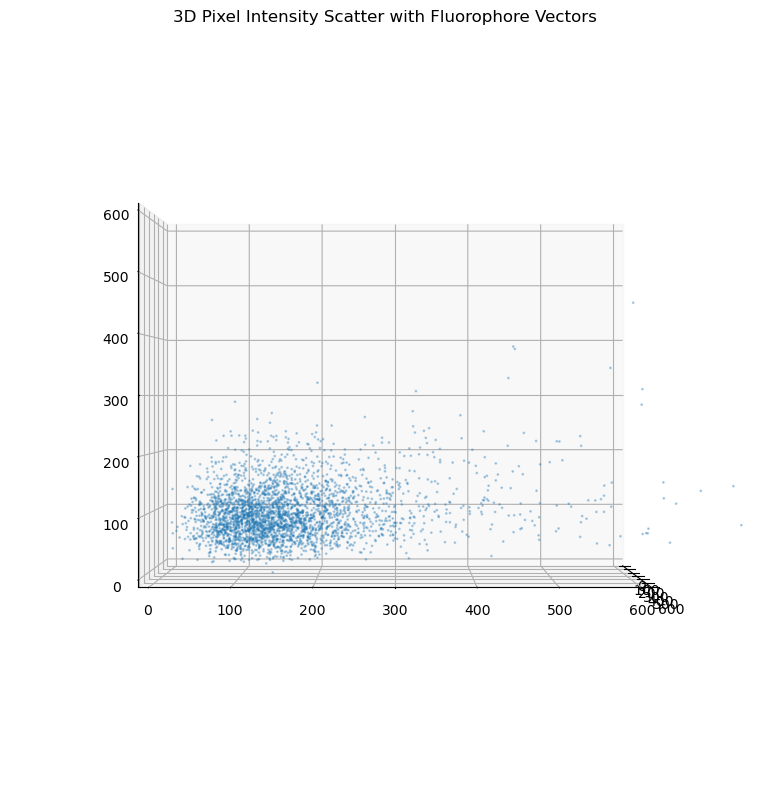

In [40]:
bound = 600

sample_size = 3000
subsampled_tiffs = []
if len(tiff_list[0]) > sample_size:
    indices = np.random.choice(len(tiff_list[0]), sample_size, replace=False)
    subsampled_tiffs = [arr[indices] for arr in tiff_list]
    print('here')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot pixel data
ax.scatter(subsampled_tiffs[0], subsampled_tiffs[1], subsampled_tiffs[2], s=1, alpha=0.3)

# Axis labels from wavelengths
#ax.set_xlabel(f'{selected_labels[0]}')
#ax.set_ylabel(f'{selected_labels[1]}')
#ax.set_zlabel(f'{selected_labels[2]}')

# Set axis bounds
ax.set_xlim(0, bound)
ax.set_ylim(0, bound)
ax.set_zlim(0, bound)


ax.view_init(elev=0, azim=0)
ax.set_title('3D Pixel Intensity Scatter with Fluorophore Vectors')
plt.tight_layout()
plt.show()